In [1]:
import socket
print(socket.gethostname())

ws-l5-011


# Multi-Layer Perceptron, MNIST
---
In this notebook, we will train an MLP to classify images from the [MNIST database](http://yann.lecun.com/exdb/mnist/) hand-written digit database.

The process will be broken down into the following steps:
>1. Load and visualize the data
2. Define a neural network
3. Train the model
4. Evaluate the performance of our trained model on a test dataset!

Before we begin, we have to import the necessary libraries for working with data and PyTorch.

In [2]:
# import libraries
import torch
import numpy as np

---
## Load and Visualize the [Data](http://pytorch.org/docs/stable/torchvision/datasets.html)

Downloading may take a few moments, and you should see your progress as the data is loading. You may also choose to change the `batch_size` if you want to load more data at a time.

This cell will create DataLoaders for each of our datasets.

In [3]:
from torchvision import datasets
import torchvision.transforms as transforms

# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 20

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# choose the training and test datasets
train_data = datasets.MNIST(root='../src/data/minist', train=True,
                                   download=True, transform=transform)
test_data = datasets.MNIST(root='../src/data/minist', train=False,
                                  download=True, transform=transform)

# prepare data loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

### Visualize a Batch of Training Data

The first step in a classification task is to take a look at the data, make sure it is loaded in correctly, then make any initial observations about patterns in that data.

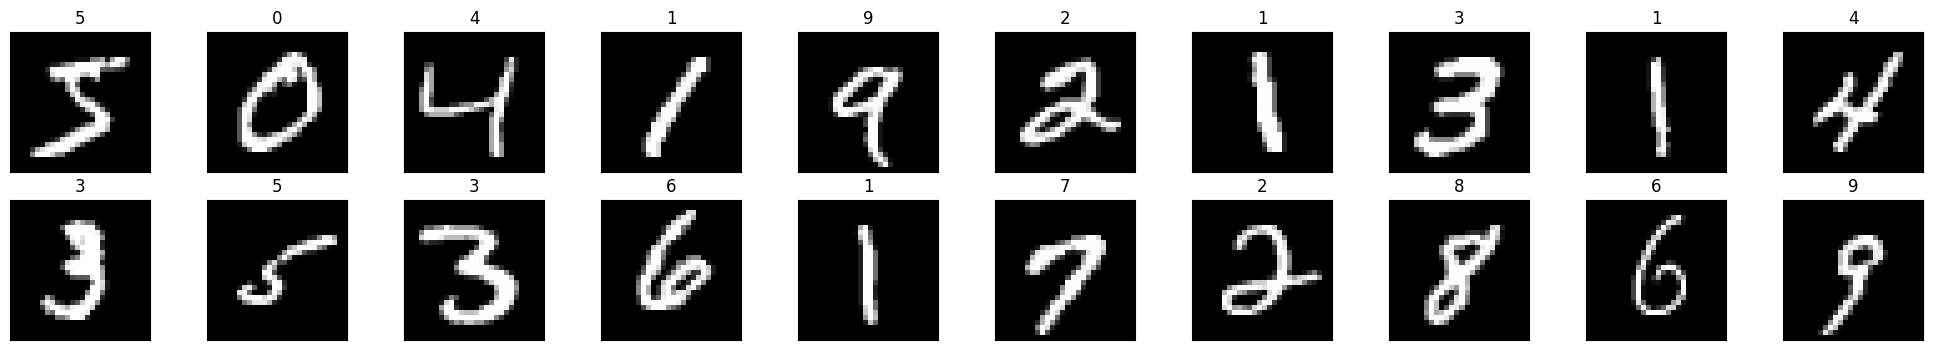

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

### View an Image in More Detail

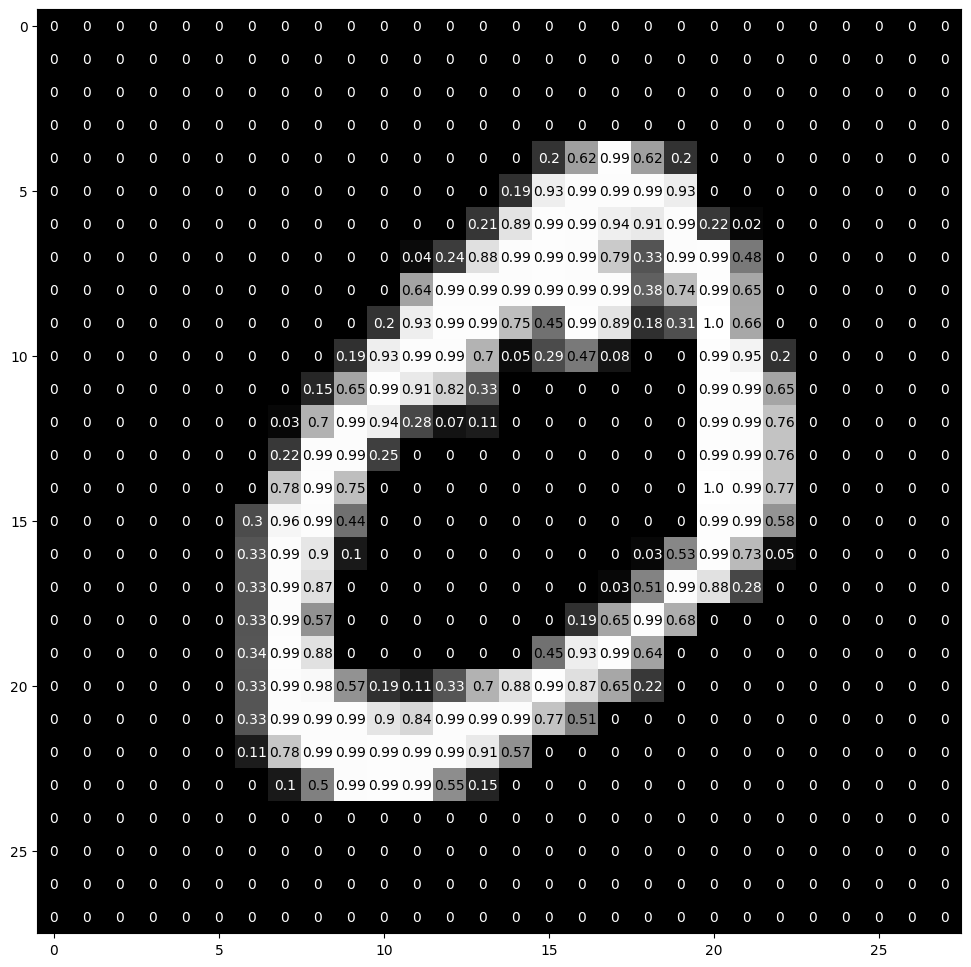

In [5]:
img = np.squeeze(images[1])

fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')

---
## Define the Network [Architecture](http://pytorch.org/docs/stable/nn.html)

The architecture will be responsible for seeing as input a 784-dim Tensor of pixel values for each image, and producing a Tensor of length 10 (our number of classes) that indicates the class scores for an input image. This particular example uses two hidden layers and dropout to avoid overfitting.

In [6]:
import torch.nn as nn
import torch.nn.functional as F

## Define the NN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        # linear layer (n_hidden -> hidden_2)
        self.fc2 = nn.Linear(512, 512)
        # linear layer (n_hidden -> 10)
        self.fc3 = nn.Linear(512, 10)
        # dropout layer (p=0.2)
        # dropout prevents overfitting of data
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # flatten image input
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x=self.dropout(x)
        x = F.relu(self.fc2(x))
        x=self.dropout(x)
        x = self.fc3(x)
        return x

# initialize the NN
model = Net()
print(model)

Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


###  Specify [Loss Function](http://pytorch.org/docs/stable/nn.html#loss-functions) and [Optimizer](http://pytorch.org/docs/stable/optim.html)

It's recommended that you use cross-entropy loss for classification. If you look at the documentation (linked above), you can see that PyTorch's cross entropy function applies a softmax funtion to the output layer *and* then calculates the log loss.

In [7]:
## Specify loss and optimization functions

# specify loss function
criterion = nn.CrossEntropyLoss()

# specify optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

---
## Train the Network

The steps for training/learning from a batch of data are described in the comments below:
1. Clear the gradients of all optimized variables
2. Forward pass: compute predicted outputs by passing inputs to the model
3. Calculate the loss
4. Backward pass: compute gradient of the loss with respect to model parameters
5. Perform a single optimization step (parameter update)
6. Update average training loss

The following loop trains for 30 epochs; feel free to change this number. For now, we suggest somewhere between 20-50 epochs. As you train, take a look at how the values for the training loss decrease over time. We want it to decrease while also avoiding overfitting the training data. 

In [8]:
n_epochs = 10  # suggest training between 20-50 epochs
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.train() # prep model for training
model.to(device)
for epoch in range(n_epochs):
    # monitor training loss
    train_loss = 0.0

    ###################
    # train the model #
    ###################
    for data, target in train_loader:
        # clear the gradients of all optimized variables
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update running training loss
        train_loss += loss.to('cpu').item()*data.size(0)

    # print training statistics
    # calculate average loss over an epoch
    train_loss = train_loss/len(train_loader.dataset)

    print('Epoch: {} \tTraining Loss: {:.6f}'.format(
        epoch+1,
        train_loss
        ))

Epoch: 1 	Training Loss: 0.834115
Epoch: 2 	Training Loss: 0.321863
Epoch: 3 	Training Loss: 0.248062
Epoch: 4 	Training Loss: 0.201987
Epoch: 5 	Training Loss: 0.171898
Epoch: 6 	Training Loss: 0.148609
Epoch: 7 	Training Loss: 0.131413
Epoch: 8 	Training Loss: 0.118010
Epoch: 9 	Training Loss: 0.105440
Epoch: 10 	Training Loss: 0.095680


---
## Test the Trained Network

Finally, we test our best model on previously unseen **test data** and evaluate it's performance. Testing on unseen data is a good way to check that our model generalizes well. It may also be useful to be granular in this analysis and take a look at how this model performs on each class as well as looking at its overall loss and accuracy.

#### `model.eval()`

`model.eval(`) will set all the layers in your model to evaluation mode. This affects layers like dropout layers that turn "off" nodes during training with some probability, but should allow every node to be "on" for evaluation!

In [9]:
# initialize lists to monitor test loss and accuracy
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # prep model for *evaluation*

for data, target in test_loader:
    # forward pass: compute predicted outputs by passing inputs to the model
    data, target = data.to(device), target.to(device)
    output = model(data)
    # calculate the loss
    loss = criterion(output, target)
    # update test loss
    test_loss += loss.to("cpu").item()*data.size(0)
   # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))
    # calculate test accuracy for each object class
    for i in range(batch_size):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# calculate and print avg test loss
test_loss = test_loss/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            str(i), 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.089280

Test Accuracy of     0: 99% (973/980)
Test Accuracy of     1: 98% (1122/1135)
Test Accuracy of     2: 96% (998/1032)
Test Accuracy of     3: 97% (988/1010)
Test Accuracy of     4: 96% (952/982)
Test Accuracy of     5: 97% (866/892)
Test Accuracy of     6: 96% (929/958)
Test Accuracy of     7: 96% (990/1028)
Test Accuracy of     8: 96% (939/974)
Test Accuracy of     9: 96% (973/1009)

Test Accuracy (Overall): 97% (9730/10000)


### Visualize Sample Test Results

This cell displays test images and their labels in this format: `predicted (ground-truth)`. The text will be green for accurately classified examples and red for incorrect predictions.

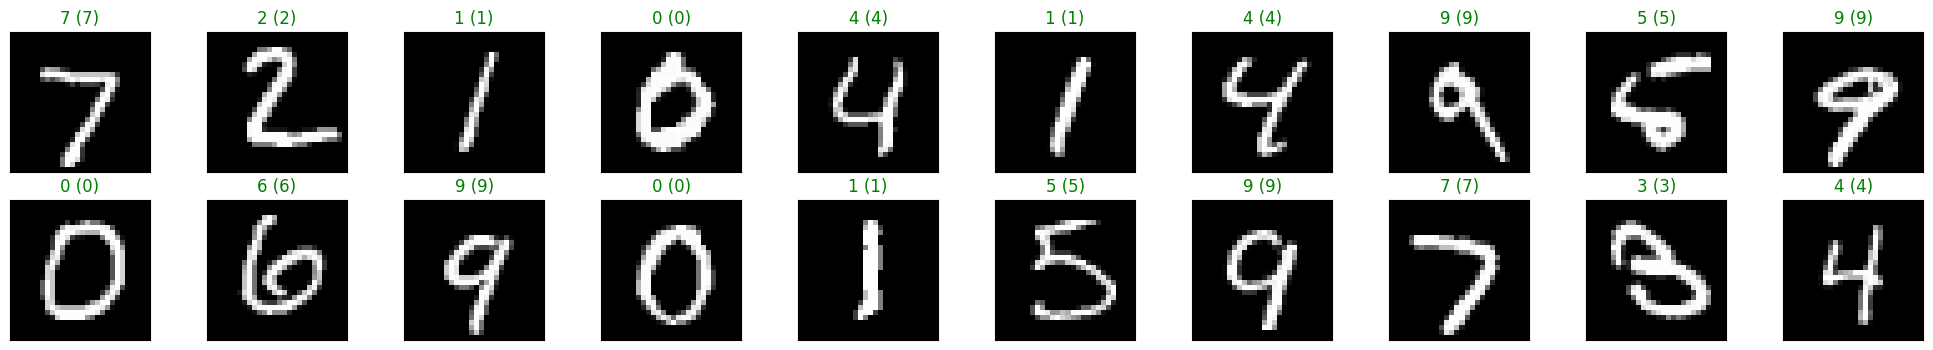

In [10]:
# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
# prep images for display
images = images.to('cpu').numpy()

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))

# Convolutional Neural Network (CNN) for MNIST classification

In [11]:
import numpy as np
import torch
import time
import platform

In [12]:
print(f'Pytorch version: {torch.__version__}')
print(f'cuda version: {torch.version.cuda}')
print(f'Python version: {platform.python_version()}')

Pytorch version: 2.6.0+cu124
cuda version: 12.4
Python version: 3.10.18


In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


## MNIST Data preparation

### Load MNIST data and normalize

In [14]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [15]:
### Load MNIST data and normalize
from src.utils.MNISTtools import load, show

In [16]:
xtrain, ltrain = load(dataset='training', path='../notebooks/data/MNIST/raw/')
xtest, ltest = load(dataset='testing', path='../notebooks/data/MNIST/raw/')

In [17]:
def normalize_MNIST_images(x):
    '''
    Args:
        x: data
    '''
    x_norm = x.astype(np.float32)
    return x_norm*2/255-1

In [18]:
# normalization
xtrain = normalize_MNIST_images(xtrain)
xtest = normalize_MNIST_images(xtest)

### Reshape
Torch expects that the input of a convolutional layer is stored in the following format
`Batch size × Number of input channels × Image width × Image height`

In [19]:
# reshape to 3d
xtrain = xtrain.reshape([28,28,-1])[:,:,None,:]
xtest = xtest.reshape([28,28,-1])[:,:,None,:]
print(f'shape of xtrain after reshape is {xtrain.shape}.')
print(f'shape of xtest after reshape is {xtest.shape}.')

shape of xtrain after reshape is (28, 28, 1, 60000).
shape of xtest after reshape is (28, 28, 1, 10000).


In [20]:
# moveaxis
xtrain = np.moveaxis(xtrain, (2,3), (1,0))
xtest = np.moveaxis(xtest, (2,3), (1,0))
print(f'shape of xtrain after moveaxis is {xtrain.shape}.')
print(f'shape of xtest after moveaxis is {xtest.shape}.')

shape of xtrain after moveaxis is (60000, 1, 28, 28).
shape of xtest after moveaxis is (10000, 1, 28, 28).


### Wrap all the data into torch Tensor

In [21]:
xtrain = torch.from_numpy(xtrain)
ltrain = torch.from_numpy(ltrain)
xtest = torch.from_numpy(xtest)
ltest = torch.from_numpy(ltest)

In [22]:
xtrain_gpu = xtrain.to(device)
ltrain_gpu = ltrain.to(device)
xtest_gpu = xtest.to(device)
ltest_gpu = ltest.to(device)

## LeNet -5 network

* Convolutional layers can be created as `nn.Conv2d(N, C, K)`. For input images of size `W×H`, the output feature maps have size `[W−K+1]x[H−K+1]`.  

* Maxpooling is implemented like any other non-linear function (such as ReLU or softmax). For input images of size `W×H`, the output feature maps have size `[W/L]×[H/L]`.  

* A fully connected layer can be created as `nn.Linear(M, N)`.

Architecture:  

(a) a convolutional layer connecting the input image to `6` feature maps with `5×5` convolutions (`K=5`) and followed by ReLU and maxpooling (`L=2`)  

(b) a convolutional layer connecting the `6` input channels to `16` output channels with `5×5` convolutions and followed by ReLU and maxpooling (`L=2`)  

(c) a fully-connected layer connecting `16` feature maps to `120` output units and followed by ReLU  

(d) a fully-connected layer connecting `120` inputs to `84` output units and followed by ReLU  

(e) a final linear layer connecting `84` inputs to `10` linear outputs (one for each of our digits)

First layer  
* input: `(28, 28, 1)`  
* after *padding*: `(32, 32, 1)`
* after convolution(kernel=`5x5`): `(28, 28, 6)` where `28=32-5+1`  
* after ReLU: `(28, 28, 6)`  
* after maxpooling(stride=`2x2`): `(14, 14, 6)` $\Rightarrow$ **OUTPUT**  


Second layer
* input: `(14, 14, 6)`
* after convolution(kernel=`5x5`): `(10, 10, 16)`
* after ReLU: `(10, 10, 16)`  
* after maxpooling(stride=`2x2`): `(5, 5, 16)` $\Rightarrow$ **OUTPUT**  


Third layer
* input: `(5, 5, 16)` $\Rightarrow$ `5x5x16=400`  
* after fully-connected: `(120, 1)`
* after ReLU: `(120, 1)` $\Rightarrow$ **OUTPUT**  


Fourth layer
* input: `(120, 1)`
* after fully-connected: `(84, 1)`
* after ReLU: `(84, 1)` $\Rightarrow$ **OUTPUT**  


Fifth layer
* input: `(84, 1)`
* after fully-connected: `(10, 1)`
* after ReLU: `(10, 1)` $\Rightarrow$ **OUTPUT**  

In [23]:
import torch.nn as nn
import torch.nn.functional as F

In [24]:
class LeNet(nn.Module):

    # network structure
    def __init__(self):
        super(LeNet, self).__init__()
        self.pad  = nn.ZeroPad2d(2)
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
        '''
        One forward pass through the network.

        Args:
            x: input
        '''
        x=self.pad(x)
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        '''
        Get the number of features in a batch of tensors `x`.
        '''
        size = x.size()[1:]
        return np.prod(size)

### Check the network structure

In [25]:
net = LeNet()
print(net)

LeNet(
  (pad): ZeroPad2d((2, 2, 2, 2))
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


### Check the network parameters

In [26]:
for name, param in net.named_parameters():
    print(name, param.size(), param.requires_grad)

conv1.weight torch.Size([6, 1, 5, 5]) True
conv1.bias torch.Size([6]) True
conv2.weight torch.Size([16, 6, 5, 5]) True
conv2.bias torch.Size([16]) True
fc1.weight torch.Size([120, 400]) True
fc1.bias torch.Size([120]) True
fc2.weight torch.Size([84, 120]) True
fc2.bias torch.Size([84]) True
fc3.weight torch.Size([10, 84]) True
fc3.bias torch.Size([10]) True


### The accuracy without backprop

In [27]:
# avoid tracking for gradient during testing and then save some computation time
with torch.no_grad():
    yinit = net(xtest)

In [28]:
_, lpred = yinit.max(1)
print(100 * (ltest == lpred).float().mean())

tensor(6.4300)


`ltest == lpred` generates a tensor with values of `0` and `1`, where `0` means inequal and `1` means equal. Therefore, `(ltest == lpred).float().mean()` implies the accuracy.

### (Mini-Batch) Stochastic Gradient Descent (SGD) with cross-entropy and momentum

**Note**: PyTorch’s CrossEntropyLoss is the composition of a softmax activation with the standard cross-entropy loss.

In [29]:
def backprop_deep(xtrain, ltrain, net, T, B=100, gamma=.001, rho=.9):
    '''
    Backprop.

    Args:
        xtrain: training samples
        ltrain: testing samples
        net: neural network
        T: number of epochs
        B: minibatch size
        gamma: step size
        rho: momentum
    '''
    N = xtrain.size()[0]     # Training set size
    NB = N//B                # Number of minibatches
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(net.parameters(), lr=gamma, momentum=rho)

    for epoch in range(T):
        running_loss = 0.0
        shuffled_indices = np.random.permutation(NB)
        for k in range(NB):
            # Extract k-th minibatch from xtrain and ltrain
            minibatch_indices = range(shuffled_indices[k]*B, (shuffled_indices[k]+1)*B)
            inputs = xtrain[minibatch_indices]
            labels = ltrain[minibatch_indices]

            # Initialize the gradients to zero
            optimizer.zero_grad()

            # Forward propagation
            outputs = net(inputs)

            # Error evaluation
            labels = labels.long()
            loss = criterion(outputs, labels)

            # Back propagation
            loss.backward()

            # Parameter update
            optimizer.step()

            # Print averaged loss per minibatch every 100 mini-batches
            # Compute and print statistics
            with torch.no_grad():
                running_loss += loss.item()
            if k % 100 == 99:
                print('[%d, %5d] loss: %.3f' %
                      (epoch + 1, k + 1, running_loss / 100))
                running_loss = 0.0

# Training and testing.

In [30]:
backprop_deep(xtrain_gpu, ltrain_gpu, net.to(device), T=10, B=100, gamma=.001, rho=.9)

[1,   100] loss: 2.302
[1,   200] loss: 2.297
[1,   300] loss: 2.291
[1,   400] loss: 2.281
[1,   500] loss: 2.265
[1,   600] loss: 2.230
[2,   100] loss: 2.131
[2,   200] loss: 1.729
[2,   300] loss: 0.940
[2,   400] loss: 0.558
[2,   500] loss: 0.423
[2,   600] loss: 0.364
[3,   100] loss: 0.328
[3,   200] loss: 0.288
[3,   300] loss: 0.266
[3,   400] loss: 0.220
[3,   500] loss: 0.225
[3,   600] loss: 0.211
[4,   100] loss: 0.195
[4,   200] loss: 0.181
[4,   300] loss: 0.180
[4,   400] loss: 0.177
[4,   500] loss: 0.162
[4,   600] loss: 0.139
[5,   100] loss: 0.157
[5,   200] loss: 0.131
[5,   300] loss: 0.136
[5,   400] loss: 0.127
[5,   500] loss: 0.130
[5,   600] loss: 0.135
[6,   100] loss: 0.129
[6,   200] loss: 0.115
[6,   300] loss: 0.126
[6,   400] loss: 0.117
[6,   500] loss: 0.104
[6,   600] loss: 0.105
[7,   100] loss: 0.097
[7,   200] loss: 0.120
[7,   300] loss: 0.101
[7,   400] loss: 0.094
[7,   500] loss: 0.099
[7,   600] loss: 0.097
[8,   100] loss: 0.087
[8,   200] 

In [31]:
def test_deep(xtest, ltest, net, B=100):
    """
    Evaluate the trained net on test set.
    Args:
        xtest: test images (e.g., xtest_gpu)
        ltest: test labels (e.g., ltest_gpu)
        net:   trained model
        B:     batch size for evaluation
    Returns:
        avg_loss (float), acc (float in [0,1])
    """
    criterion = nn.CrossEntropyLoss()
    net.eval()

    N = xtest.size(0)
    NB = (N + B - 1) // B
    total_loss = 0.0
    correct = 0

    with torch.no_grad():
        for k in range(NB):
            s, e = k * B, min((k + 1) * B, N)
            inputs = xtest[s:e]                 # already on GPU if *_gpu
            labels = ltest[s:e].long()
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * (e - s)
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()

    avg_loss = total_loss / N
    acc = correct / N
    print(f"Test loss: {avg_loss:.4f}, acc: {acc*100:.2f}%")
    return avg_loss, acc

In [32]:
test_deep(xtest_gpu, ltest_gpu, net.to(device), B=100)

Test loss: 0.0684, acc: 97.88%


(0.06842744546418544, 0.9788)

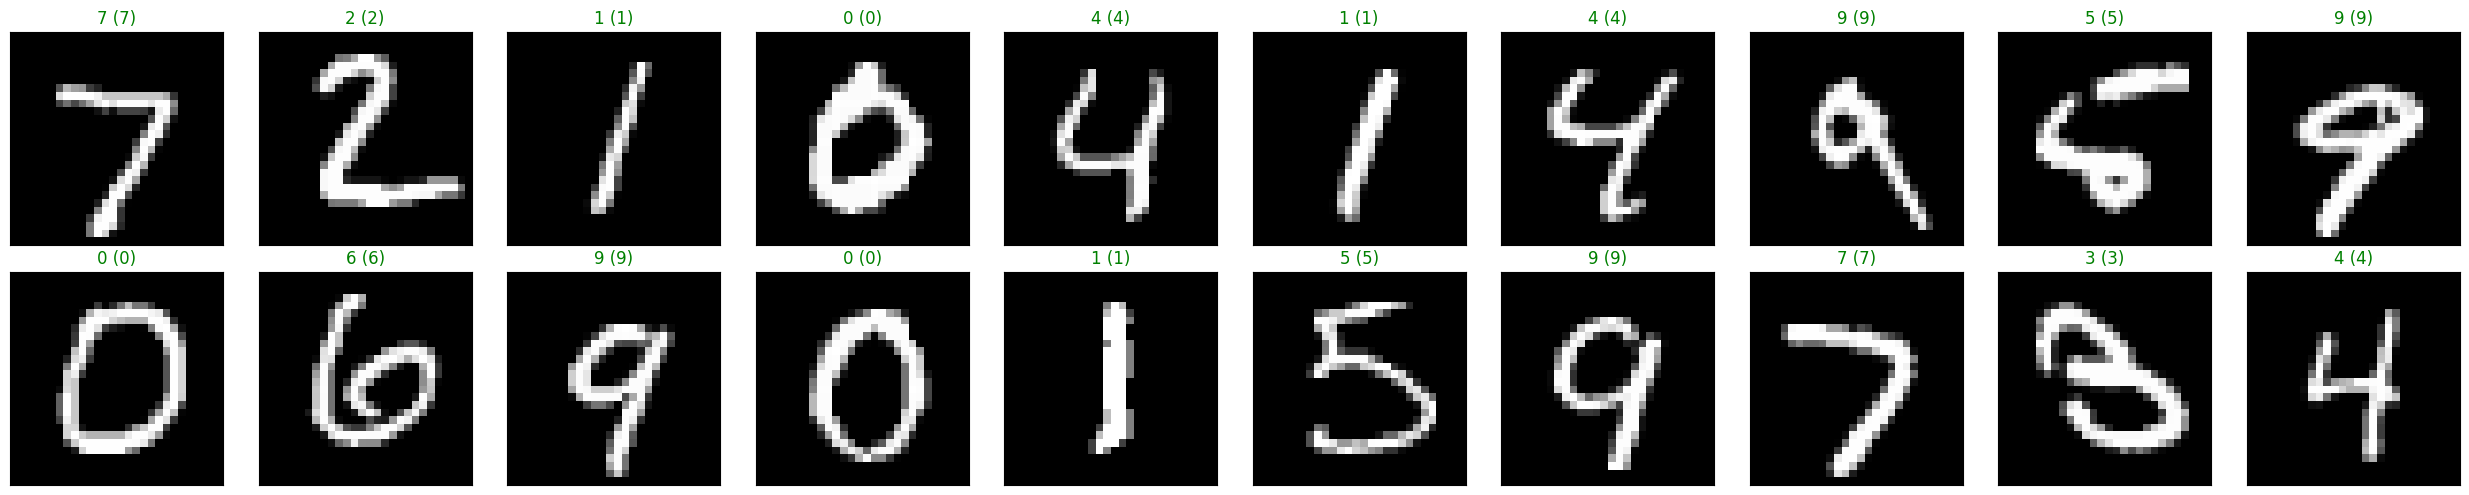

In [33]:
disp_B = min(20, xtest_gpu.size(0))
imgs   = xtest_gpu[:disp_B]
labs   = ltest_gpu[:disp_B].long()

net.eval()
with torch.no_grad():
    outs  = net(imgs)
    preds = outs.argmax(dim=1)

imgs_np = imgs.detach().to("cpu").numpy()
labs_np = labs.detach().to("cpu").numpy()
pred_np = preds.detach().to("cpu").numpy()

rows = 2
cols = int(np.ceil(disp_B / rows))
fig = plt.figure(figsize=(cols*2.5, rows*2.5))
for idx in range(disp_B):
    ax = fig.add_subplot(rows, cols, idx + 1, xticks=[], yticks=[])
    # imgs shape: (N, 1, H, W) -> squeeze 掉通道维
    ax.imshow(np.squeeze(imgs_np[idx]), cmap="gray")
    ok = (pred_np[idx] == labs_np[idx])
    ax.set_title(f"{pred_np[idx]} ({labs_np[idx]})", color=("green" if ok else "red"))

plt.tight_layout()
plt.show()


### Extensive Task

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from torchvision import models

IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406], device="cuda" if torch.cuda.is_available() else "cpu").view(1,3,1,1)
IMNET_STD  = torch.tensor([0.229, 0.224, 0.225], device=IMNET_MEAN.device).view(1,3,1,1)


def preprocess_imagenet_batch(x, device, target_size=224):
    """
    x: (B,1,28,28) 或 (B,3,H,W), uint8/float皆可
    按 batch 在 GPU 上做：转 float、通道扩展、插值、标准化、channels_last
    """
    # x = x.to(device, non_blocking=True)
    if x.dtype != torch.float32 and x.dtype != torch.float16:
        x = x.float()
        # 如果你的原始数据是 [0,255] 的 uint8，则做归一化
        if x.max() > 1.5:
            x = x / 255.0

    # 灰度转3通道（不复制整数据集，而是当前批次）
    if x.size(1) == 1:
        x = x.expand(-1, 3, -1, -1)

    # 只在需要时才放大到 target_size，避免多余显存消耗
    if target_size is not None and (x.shape[-1] != target_size or x.shape[-2] != target_size):
        x = F.interpolate(x, size=(target_size, target_size), mode="bilinear", align_corners=False)

    # ImageNet 归一化
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
    x = (x - mean) / std

    # 改为 channels_last，利于卷积显存/速度
    return x.contiguous(memory_format=torch.channels_last)

def train_eval_model(model, xtrain, ltrain, xtest, ltest, epochs=5, batch_size=32, lr=1e-3, momentum=0.9, weight_decay=1e-4, target_size=224):
    device = next(model.parameters()).device

    # 模型/输入都用 channels_last
    model = model.to(memory_format=torch.channels_last)

    # DataLoader 都用 CPU tensor，pin_memory=True
    train_loader = DataLoader(TensorDataset(xtrain, ltrain.long()), batch_size=batch_size, shuffle=True, pin_memory=False, num_workers=0)
    test_loader  = DataLoader(TensorDataset(xtest,  ltest.long()),  batch_size=batch_size, shuffle=False, pin_memory=False, num_workers=0)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    # AMP 混合精度
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    best_acc = 0.0
    torch.backends.cudnn.benchmark = True

    for ep in range(1, epochs+1):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:

            # 按 batch 预处理 + 送到 GPU
            xb = preprocess_imagenet_batch(xb, device, target_size=target_size)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * yb.size(0)

        # 评估
        model.eval()
        correct = 0
        total = 0
        test_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                yb = yb.to(device, non_blocking=True)
                xb = preprocess_imagenet_batch(xb, device, target_size=target_size)
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    logits = model(xb)
                    loss = criterion(logits, yb)
                test_loss += loss.item() * yb.size(0)
                pred = logits.argmax(1)
                correct += (pred == yb).sum().item()
                total += yb.size(0)

        avg_train_loss = running_loss / len(train_loader.dataset)
        avg_test_loss  = test_loss   / len(test_loader.dataset)
        acc = correct / total
        best_acc = max(best_acc, acc)
        print(f"Epoch {ep:2d} | train_loss={avg_train_loss:.4f} | test_loss={avg_test_loss:.4f} | acc={acc:.4f}")

        # 释放一些临时显存
        torch.cuda.empty_cache()

    return best_acc, avg_test_loss

# ---------- ResNet18 / DenseNet121 ----------
def run_resnet18_and_densenet121(xtrain_gpu, ltrain_gpu, xtest_gpu, ltest_gpu, use_pretrained=False, epochs=5):
    device = xtrain_gpu.device

    # ResNet18
    resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if use_pretrained else None)
    resnet.fc = nn.Linear(resnet.fc.in_features, 10)
    resnet = resnet.to(device)
    print("\n=== Training ResNet18 ===")
    resnet_best_acc, resnet_test_loss = train_eval_model(resnet, xtrain_gpu, ltrain_gpu, xtest_gpu, ltest_gpu, epochs=epochs)

    # DenseNet121
    densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if use_pretrained else None)
    densenet.classifier = nn.Linear(densenet.classifier.in_features, 10)
    densenet = densenet.to(device)
    print("\n=== Training DenseNet121 ===")
    dense_best_acc, dense_test_loss = train_eval_model(densenet, xtrain_gpu, ltrain_gpu, xtest_gpu, ltest_gpu, epochs=epochs)

    return {
        "ResNet18": {"best_acc": resnet_best_acc, "last_test_loss": resnet_test_loss},
        "DenseNet121": {"best_acc": dense_best_acc, "last_test_loss": dense_test_loss},
    }

In [41]:
results = run_resnet18_and_densenet121(xtrain_gpu, ltrain_gpu, xtest_gpu, ltest_gpu, use_pretrained=False, epochs=5)


=== Training ResNet18 ===


/tmp/slurm-maosheng.li-91430/ipykernel_692049/2477018300.py:50: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/slurm-maosheng.li-91430/ipykernel_692049/2477018300.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/slurm-maosheng.li-91430/ipykernel_692049/2477018300.py:84: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch  1 | train_loss=0.3723 | test_loss=0.0960 | acc=0.9717
Epoch  2 | train_loss=0.0658 | test_loss=0.0494 | acc=0.9857
Epoch  3 | train_loss=0.0410 | test_loss=0.0357 | acc=0.9901
Epoch  4 | train_loss=0.0314 | test_loss=0.0264 | acc=0.9922
Epoch  5 | train_loss=0.0243 | test_loss=0.0259 | acc=0.9924

=== Training DenseNet121 ===
Epoch  1 | train_loss=0.5980 | test_loss=0.1489 | acc=0.9654
Epoch  2 | train_loss=0.1004 | test_loss=0.0624 | acc=0.9841
Epoch  3 | train_loss=0.0651 | test_loss=0.0456 | acc=0.9866
Epoch  4 | train_loss=0.0491 | test_loss=0.0400 | acc=0.9881
Epoch  5 | train_loss=0.0392 | test_loss=0.0355 | acc=0.9900
